# Unified WSSS: DINOv3 + SAM Distillation

This notebook trains a weakly supervised segmentation pipeline using cached DINOv3 features and SAM-generated pseudo masks.

In [2]:
import os
import random
from typing import List, Tuple, Callable, Any

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.notebook import tqdm

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

from dataset import (
    make_voc_datasets, 
    VOC_CLASSES, 
    denorm_to_uint8,
    get_wsss_dataloaders,
    cache_dino_tokens
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dino_model = torch.hub.load(
    "./dinov3",
    "dinov3_vitl16",
    source="local",
    weights="dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth",
).to(device)
dino_model.eval()

sam2_model = build_sam2("configs/sam2.1/sam2.1_hiera_s.yaml", "./sam2.1_hiera_small.pt", device=device)
predictor = SAM2ImagePredictor(sam2_model)
print("Models loaded.")

Using device: cuda
Models loaded.


### Data Loading

We use PASCAL VOC and derive image-level tags from the segmentation masks.

In [3]:
batch_size = 16
num_workers = min(4, os.cpu_count() or 1)

voc_segmentation, val_dataset = make_voc_datasets(root="./data", resize_size=448)

dataloader, seq_dataloader, val_dataloader = get_wsss_dataloaders(
    train_ds=voc_segmentation,
    val_ds=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers
)

print(f"VOC train set: {len(voc_segmentation)} images across {num_workers} workers.")

VOC train set: 1464 images across 4 workers.


### Segmenter

The segmenter maps cached DINO patch tokens to dense class logits.

In [4]:
class UnifiedWSSSSegmenter(nn.Module):
    def __init__(self, in_channels=1024, num_classes=20):
        super().__init__()
        self.in_channels = in_channels
        self.decoder = nn.Sequential(
            nn.Conv2d(in_channels, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1),
        )

    def forward(self, patch_tokens, grid_size, target_size):
        x = patch_tokens.permute(0, 2, 1).reshape(-1, self.in_channels, *grid_size)
        logits = self.decoder(x)
        dense_logits = F.interpolate(logits, size=target_size, mode='bilinear', align_corners=False)
        image_level_logits = dense_logits.amax(dim=(2, 3))
        return image_level_logits, dense_logits

    @torch.no_grad()
    def predict(self, patch_tokens, grid_size, target_size, bg_threshold=0.5):
        """
        Directly predict the discrete class mask (0=bg, 1..20=classes).
        """
        _, dense_logits = self.forward(patch_tokens, grid_size, target_size)
        probs = torch.sigmoid(dense_logits)
        
        B, _, H, W = probs.shape
        bg_prob = torch.full((B, 1, H, W), bg_threshold, device=probs.device)
        full_probs = torch.cat([bg_prob, probs], dim=1)
        return full_probs.argmax(dim=1)

### Training

The model is trained with image-level tags and SAM-generated pseudo masks.

In [5]:
dino_cache_tensor, train_labels = cache_dino_tokens(
    dino_model,
    voc_segmentation,
    seq_dataloader,
    device=device
)

Caching DINO:   0%|          | 0/92 [00:00<?, ?it/s]

Caching DINO: Cached 1464 samples (2.19 GB on cuda).


Loading checkpoint from wsss_checkpoint.pth...
Resuming from epoch 30
Starting unified distillation.


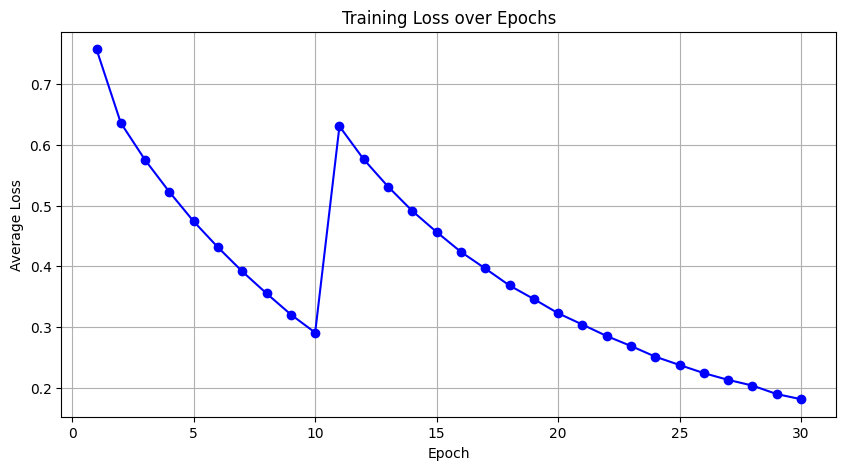

In [ ]:
# ==========================================
# Parameters & Configuration
# ==========================================
NUM_EPOCHS: int = 30
BURN_IN_EPOCHS: int = 1
LEARNING_RATE: float = 1e-4
CHECKPOINT_PATH: str = "wsss_checkpoint.pth"
DEVICE: torch.device = device 

# Structural constants extracted from the code
NUM_CLASSES: int = 20
CAM_THRESHOLD: float = 0.4     # Threshold for CAM to determine active mask box

# ==========================================
# Loss Functions
# ==========================================
def seg_bce_dice_loss(preds: torch.Tensor, targets: torch.Tensor, dice_weight: float = 0.5, dice_smoothing: float = 1.0) -> torch.Tensor:
    """
    Calculates combined BCE and Dice loss directly (Truth vs Output).
    Expected shape for preds and targets: (N, H, W) where N is active classes in batch.
    """
    bce = F.binary_cross_entropy_with_logits(preds, targets)

    # DICE loss
    probs = torch.sigmoid(preds)
    intersection = (probs * targets).sum()
    union = probs.sum() + targets.sum()
    dice = 1 - (2.0 * intersection + dice_smoothing) / (union + dice_smoothing)

    return bce + (dice_weight * dice)

# Interchangeable loss aliases
cls_loss_fn = nn.BCEWithLogitsLoss()
seg_loss_fn = seg_bce_dice_loss

# ==========================================
# Helper Functions
# ==========================================
@torch.no_grad()
def generate_sam_pseudo_labels(
    images: torch.Tensor, 
    dense_logits: torch.Tensor, 
    image_level_labels: torch.Tensor, 
    predictor: Any, 
    device: torch.device,
    cam_threshold: float = 0.4
) -> torch.Tensor:
    """Generates pseudo labels using SAM given predicted CAMs."""
    B, _, H, W = images.shape
    pseudo_labels_batch = torch.zeros((B, NUM_CLASSES, H, W), dtype=torch.float32, device=device)

    for b_idx in range(B):
        active_classes = torch.where(image_level_labels[b_idx] > 0)[0]
        if len(active_classes) == 0:
            continue

        # Un-batched: explicitly set each image
        img_np = denorm_to_uint8(images[b_idx])
        predictor.set_image(img_np)

        C_num = len(active_classes)
        cam_active = dense_logits[b_idx, active_classes].detach()
        cam_flat = cam_active.view(C_num, -1)
        cam_min = cam_flat.min(dim=1, keepdim=True)[0]
        cam_max = cam_flat.max(dim=1, keepdim=True)[0]
        cam_norm = (cam_flat - cam_min) / (cam_max - cam_min + 1e-8)
        cam_norm_2d = cam_norm.view(C_num, H, W)

        max_flat = cam_norm.argmax(dim=1)
        max_y = torch.div(max_flat, W, rounding_mode='trunc')
        max_x = (max_flat % W)

        mask_bool = cam_norm_2d > cam_threshold

        y_idx = torch.arange(H, device=device).view(1, H, 1).expand(C_num, H, W)
        x_idx = torch.arange(W, device=device).view(1, 1, W).expand(C_num, H, W)

        y_min = torch.where(mask_bool, y_idx, H).amin(dim=(1, 2)).clamp(min=0, max=H)
        y_max = torch.where(mask_bool, y_idx, -1).amax(dim=(1, 2)).clamp(min=0, max=H)
        x_min = torch.where(mask_bool, x_idx, W).amin(dim=(1, 2)).clamp(min=0, max=W)
        x_max = torch.where(mask_bool, x_idx, -1).amax(dim=(1, 2)).clamp(min=0, max=W)

        valid_box = y_min <= y_max

        for c in range(C_num):
            pt = np.array([[max_x[c].item(), max_y[c].item()]], dtype=np.float32)
            lbl = np.array([1], dtype=np.int32)
            c_box = np.array([x_min[c].item(), y_min[c].item(), x_max[c].item(), y_max[c].item()], dtype=np.float32) if valid_box[c] else None

            masks, _, _ = predictor.predict(
                point_coords=pt,
                point_labels=lbl,
                box=c_box,
                multimask_output=False,
                return_logits=False,
            )
            # SAM returns boolean array typically [1, H, W] for single mask out
            pseudo_labels_batch[b_idx, active_classes[c]] = torch.tensor(masks).squeeze().to(device).float()
            
    return pseudo_labels_batch

def train_one_epoch(
    epoch: int, 
    dataloader: DataLoader, 
    model: nn.Module, 
    optimizer: optim.Optimizer, 
    cls_loss_fn: Callable, 
    seg_loss_fn: Callable, 
    predictor: Any, 
    dino_cache: torch.Tensor, 
    device: torch.device, 
    is_burn_in: bool
) -> float:
    model.train()
    epoch_total_loss = 0.0
    num_batches = 0

    desc = f"Epoch {epoch + 1} Distillation {'(Burn-in)' if is_burn_in else ''}"
    for indices, images, image_level_labels, _ in tqdm(dataloader, desc=desc):
        images = images.to(device, non_blocking=True)
        image_level_labels = image_level_labels.to(device, non_blocking=True)
        B, _, H, W = images.shape

        optimizer.zero_grad(set_to_none=True)

        patch_tokens = dino_cache[indices].float()
        grid_dim = int(patch_tokens.shape[1] ** 0.5)
        
        # Forward pass
        img_logits, dense_logits = model(
            patch_tokens,
            grid_size=(grid_dim, grid_dim),
            target_size=(H, W),
        )
        
        # 1. Classification loss (Image level)
        total_loss = cls_loss_fn(img_logits, image_level_labels)

        # 2. Segmentation Distillation loss
        if not is_burn_in:
            pseudo_labels = generate_sam_pseudo_labels(
                images, dense_logits, image_level_labels, predictor, device,
                cam_threshold=CAM_THRESHOLD
            )
            
            # Decouple the segmentation loss map: only process loss on active classes directly (Truth vs Output)
            b_idx, c_idx = torch.where(image_level_labels > 0)
            if len(b_idx) > 0:
                active_preds = dense_logits[b_idx, c_idx]
                active_targets = pseudo_labels[b_idx, c_idx]
                total_loss += seg_loss_fn(active_preds, active_targets)

        total_loss.backward()
        optimizer.step()

        epoch_total_loss += total_loss.item()
        num_batches += 1

    return epoch_total_loss / max(1, num_batches)

def plot_losses(losses: List[float], save_path: str = 'loss_curve.png') -> None:
    if not losses:
        return
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='b')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()

# ==========================================
# Main Execution
# ==========================================
model = UnifiedWSSSSegmenter(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

start_epoch = 0
epoch_losses = []

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    epoch_losses = checkpoint.get('epoch_losses', [])
    print(f"Resuming from epoch {start_epoch}")

print("Starting unified distillation.")

for epoch in range(start_epoch, NUM_EPOCHS):
    is_burn_in = epoch < BURN_IN_EPOCHS
    
    avg_loss = train_one_epoch(
        epoch=epoch,
        dataloader=dataloader,
        model=model,
        optimizer=optimizer,
        cls_loss_fn=cls_loss_fn,
        seg_loss_fn=seg_loss_fn,
        predictor=predictor,
        dino_cache=dino_cache_tensor,
        device=DEVICE,
        is_burn_in=is_burn_in
    )
    
    epoch_losses.append(avg_loss)

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch_losses': epoch_losses,
    }, CHECKPOINT_PATH)

plot_losses(epoch_losses)

In [7]:
from dataset import evaluate_masks

def calculate_miou(model, dino_model, dataloader, device):
    model.eval()
    dino_model.eval()

    intersection = torch.zeros(21, device=device)
    union = torch.zeros(21, device=device)

    print("Evaluating validation mIoU...")
    with torch.inference_mode():
        for indices, images, labels, masks in tqdm(dataloader):
            images = images.to(device, non_blocking=True)
            features = dino_model.forward_features(images)
            patch_tokens = features['x_norm_patchtokens'].float()

            grid_dim = int(patch_tokens.shape[1] ** 0.5)
            target_size = (images.shape[2], images.shape[3])

            preds = model.predict(patch_tokens, grid_size=(grid_dim, grid_dim), target_size=target_size, bg_threshold=0.5)

            for b in range(len(masks)):
                mask_t = masks[b].to(device)
                H, W = mask_t.shape
                
                # Resize the prediction (e.g. 448x448) back to the original mask dimensions
                pred_b = preds[b:b+1].float().unsqueeze(0)
                p = F.interpolate(pred_b, size=(H, W), mode="nearest-exact").squeeze(0).squeeze(0)
                
                # Use standard evaluation from dataset.py
                b_int, b_uni, _ = evaluate_masks(p, mask_t, num_classes=21, ignore_index=255)
                intersection += b_int
                union += b_uni

    iou = intersection / union.clamp(min=1e-8)

    print("\nValidation results")
    for c, name in enumerate(['background'] + VOC_CLASSES):
        if union[c] > 0:
            print(f"{name.ljust(15)}: {iou[c].item():.4f}")

    miou = iou[union > 0].mean().item()
    print(f"mIoU: {miou:.4f}")

    return miou

val_miou = calculate_miou(model, dino_model, val_dataloader, device)

Evaluating validation mIoU...


  0%|          | 0/91 [00:00<?, ?it/s]


Validation results
background     : 0.8956
aeroplane      : 0.8887
bicycle        : 0.4392
bird           : 0.9107
boat           : 0.7776
bottle         : 0.6866
bus            : 0.9524
car            : 0.0409
cat            : 0.9664
chair          : 0.4151
cow            : 0.7335
diningtable    : 0.2889
dog            : 0.9432
horse          : 0.8740
motorbike      : 0.8753
person         : 0.7578
pottedplant    : 0.3331
sheep          : 0.7567
sofa           : 0.6568
train          : 0.9245
tvmonitor      : 0.7540
mIoU: 0.7081


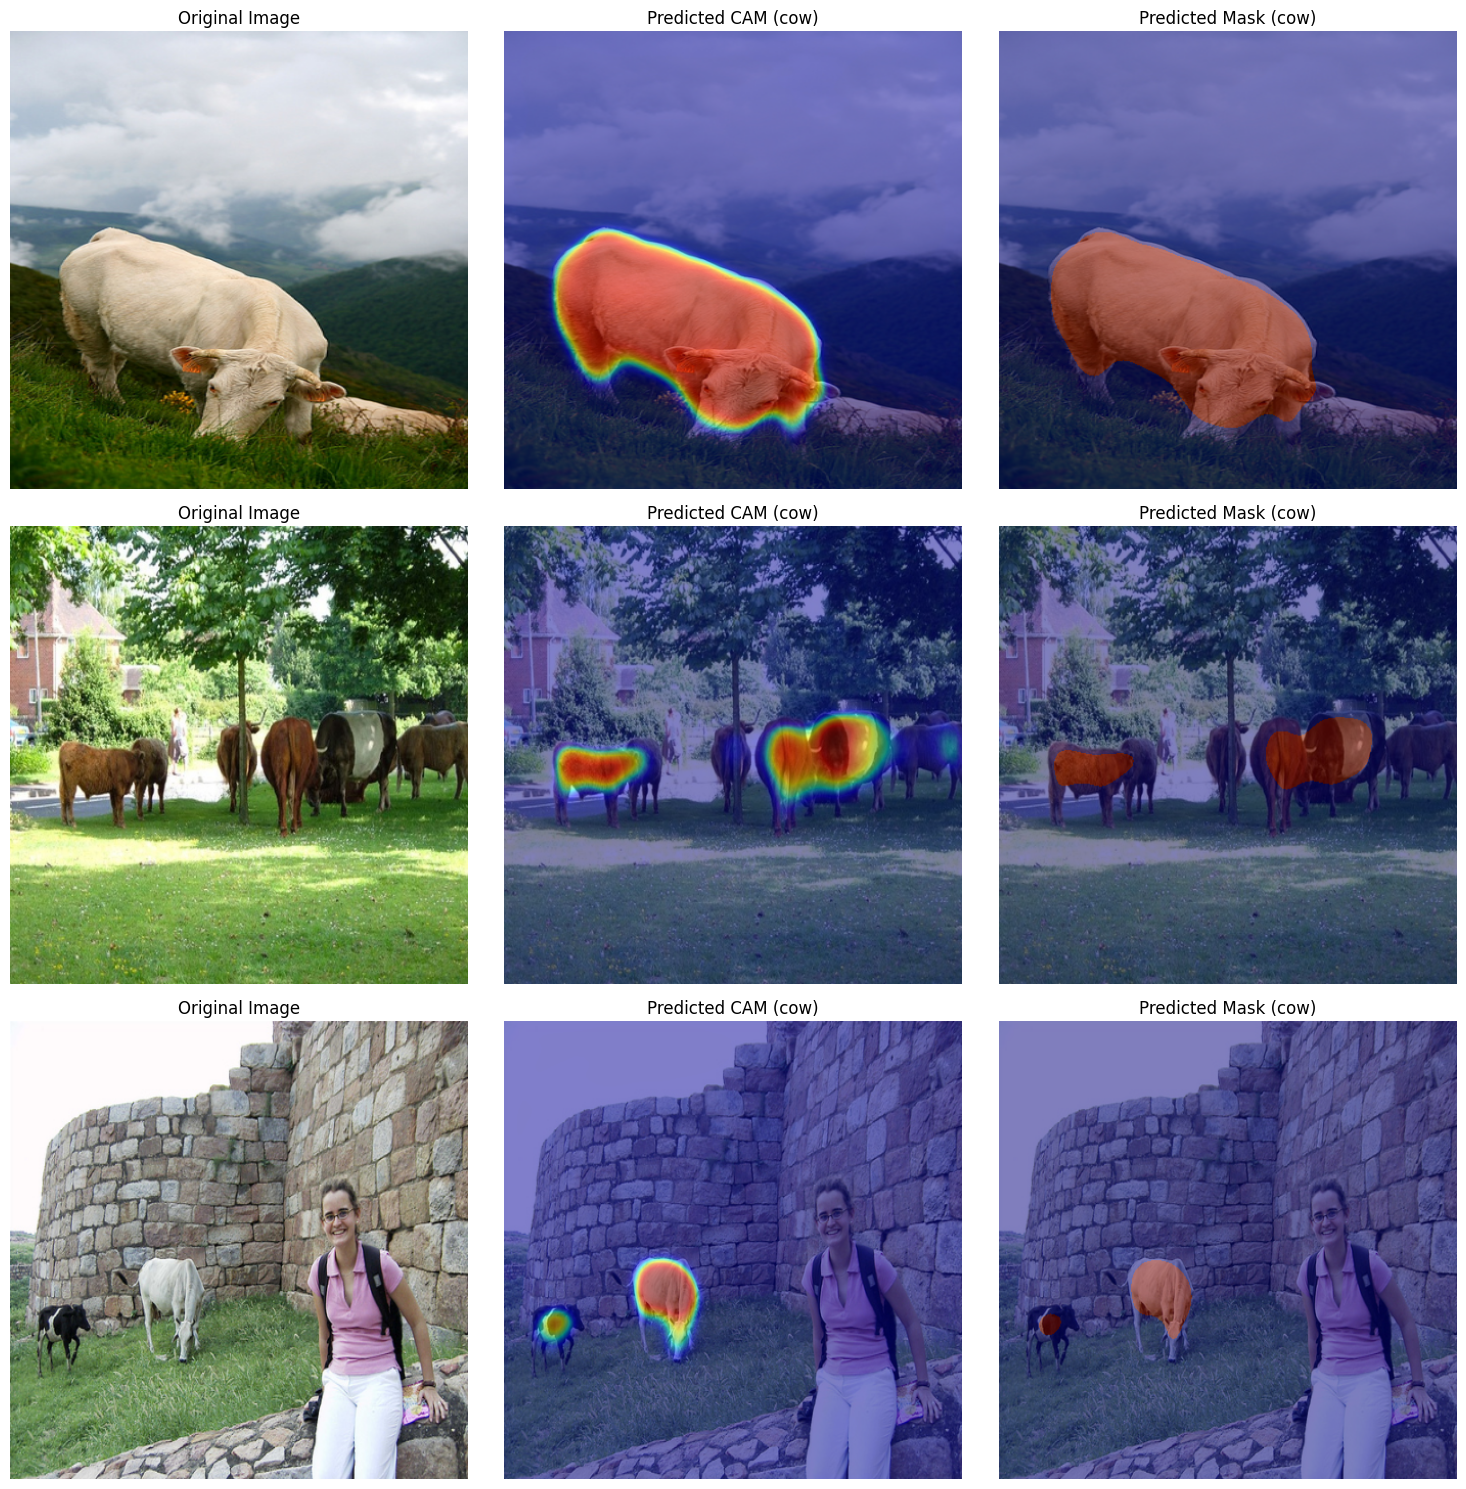

In [8]:
def visualize_results(model, dataset, num_images=4, epoch=None, target_class=None):
    model.eval()

    c_target = None
    if target_class is not None:
        c_target = VOC_CLASSES.index(target_class) if isinstance(target_class, str) else target_class
        indices = []
        attempts = 0
        while len(indices) < num_images and attempts < 1000:
            idx = random.randint(0, len(dataset) - 1)
            _, _, label_vec, _ = dataset[idx]
            if label_vec[c_target] > 0 and idx not in indices:
                indices.append(idx)
            attempts += 1
        num_images = len(indices)
        if num_images == 0:
            print(f"No images found for class '{target_class}'.")
            return
    else:
        indices = random.sample(range(len(dataset)), num_images)

    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    if num_images == 1:
        axes = [axes]
    if epoch is not None:
        fig.suptitle(f"Epoch {epoch} Results", fontsize=16)

    for idx, row in zip(indices, axes):
        _, img_t, label_vec, _ = dataset[idx]
        with torch.no_grad():
            patch_tokens = dino_cache_tensor[idx].unsqueeze(0).float()
            grid_dim = int(patch_tokens.shape[1] ** 0.5)
            _, dense_logits = model(
                patch_tokens,
                grid_size=(grid_dim, grid_dim),
                target_size=(img_t.shape[1], img_t.shape[2]),
            )
            pred_probs = torch.sigmoid(dense_logits)[0].cpu()

        img_vis = denorm_to_uint8(img_t)

        c_idx = c_target
        if c_idx is None:
            active_classes = torch.where(label_vec > 0)[0]
            c_idx = active_classes[0] if len(active_classes) > 0 else None

        row[0].imshow(img_vis)
        row[0].set_title("Original Image")
        row[0].axis('off')

        if c_idx is not None:
            class_name = VOC_CLASSES[c_idx]
            cam = pred_probs[c_idx].numpy()
            row[1].imshow(img_vis)
            row[1].imshow(cam, cmap='jet', alpha=0.5)
            row[1].set_title(f"Predicted CAM ({class_name})")
            row[1].axis('off')
            mask = (cam > 0.5).astype(float)
            row[2].imshow(img_vis)
            row[2].imshow(mask, cmap='jet', alpha=0.5)
            row[2].set_title(f"Predicted Mask ({class_name})")
            row[2].axis('off')
        else:
            row[1].axis('off')
            row[2].axis('off')

    plt.tight_layout()
    if epoch is not None:
        plt.subplots_adjust(top=0.95)
    plt.show()

visualize_results(model, voc_segmentation, num_images=3, target_class='cow')